In [34]:
# -*- coding: utf-8 -*-
from DATA.stock_invest_function import *
from __future__ import annotations
import pandas as pd
from sqlalchemy import create_engine, text
from dateutil.relativedelta import relativedelta
import warnings
warnings.filterwarnings("ignore")

matplotlib.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

import matplotlib.pyplot as plt

In [35]:

# ====== 0) DB 연결 ======
def make_engine(db_info: dict):
    """
    db_info 예시:
    db_info = {
        "host": "...",
        "port": 3307,
        "user": "...",
        "password": "...",
        "database": "investar"
    }
    """
    url = (
        f"mysql+pymysql://{db_info['user']}:{db_info['password']}"
        f"@{db_info['host']}:{db_info['port']}/{db_info['database']}?charset=utf8mb4"
    )
    return create_engine(url, pool_recycle=3600)

# ====== 1) hs_code별 피벗 테이블 ======
def get_pivot_by_hscode(
    engine,
    hs_code: str,
    table: str = "korea_monthly_trade_forecast_v2",
    indicators: list[str] | None = None,
    use_latest_forecast_date: bool = True,
) -> pd.DataFrame:
    """
    - hs_code의 모든 row를 불러와서
      index=date, columns=indicator, values=value 형태의 피벗을 만듭니다.
    - 동일 key(date, hs_code, indicator)에 여러 행이 있으면 forecast_date가 최신인 것만 사용합니다.
    - indicators가 주어지면 해당 indicator만 포함합니다.
    """
    params = {"hs_code": hs_code}

    # 최신 forecast_date 선별 서브쿼리
    latest_join = ""
    if use_latest_forecast_date:
        latest_join = f"""
            JOIN (
                SELECT date, hs_code, indicator, MAX(forecast_date) AS max_fd
                FROM {table}
                GROUP BY date, hs_code, indicator
            ) L
              ON T.date = L.date AND T.hs_code = L.hs_code
             AND T.indicator = L.indicator AND T.forecast_date = L.max_fd
        """

    # indicator 필터
    ind_filter = ""
    if indicators:
        # 안전한 바인딩을 위해 IN (:i0, :i1, ...)
        in_keys = []
        for i, ind in enumerate(indicators):
            key = f"i{i}"
            in_keys.append(f":{key}")
            params[key] = ind
        ind_filter = f"AND T.indicator IN ({', '.join(in_keys)})"

    sql = text(f"""
        SELECT
            CAST(T.date AS DATE) AS date,
            T.hs_code,
            T.indicator,
            T.value
        FROM {table} T
        {latest_join}
        WHERE T.hs_code = :hs_code
        {ind_filter}
        ORDER BY date ASC
    """)
    df = pd.read_sql(sql, engine, params=params)
    if df.empty:
        return pd.DataFrame()

    df["date"] = pd.to_datetime(df["date"])
    pv = df.pivot_table(index="date", columns="indicator", values="value", aggfunc="last").sort_index()
    pv.index.name = "date"
    return pv


# ====== 2) 두 날짜 사이 기간 변화 (절대/증감률) ======
def get_period_change(
    engine,
    date1: str,
    date2: str,
    hs_code: str,
    indicator: str,
    table: str = "korea_monthly_trade_forecast_v2",
    use_latest_forecast_date: bool = True,
) -> dict:
    """
    - (date1, date2, hs_code, indicator)의 value를 비교해 절대/증감률 반환
    - 한쪽 날짜가 없어도 안전하게 처리하고, 어떤 날짜가 누락인지 note로 알려줍니다.
    """
    params = {"hs_code": hs_code, "indicator": indicator, "d1": date1, "d2": date2}

    latest_join = ""
    if use_latest_forecast_date:
        latest_join = f"""
            JOIN (
                SELECT date, hs_code, indicator, MAX(forecast_date) AS max_fd
                FROM {table}
                GROUP BY date, hs_code, indicator
            ) L
              ON T.date = L.date AND T.hs_code = L.hs_code
             AND T.indicator = L.indicator AND T.forecast_date = L.max_fd
        """

    sql = text(f"""
        SELECT CAST(T.date AS DATE) AS date, T.value
        FROM {table} T
        {latest_join}
        WHERE T.hs_code   = :hs_code
          AND T.indicator = :indicator
          AND T.date IN (:d1, :d2)
        ORDER BY T.date
    """)
    df = pd.read_sql(sql, engine, params=params)

    # 안전 처리: 인덱스로 바꿔 dict처럼 조회
    out = {
        "hs_code": hs_code,
        "indicator": indicator,
        "date1": date1,
        "date2": date2,
        "value_date1": None,
        "value_date2": None,
        "abs_change": None,
        "pct_change": None,
        "note": None,
    }

    if df.empty:
        out["note"] = "두 날짜 모두 조회되지 않았습니다."
        return out

    df["date"] = pd.to_datetime(df["date"]).dt.normalize()
    s = df.set_index("date")["value"]

    d1 = pd.to_datetime(date1).normalize()
    d2 = pd.to_datetime(date2).normalize()

    v1 = s.get(d1, None)
    v2 = s.get(d2, None)

    out["value_date1"] = float(v1) if v1 is not None else None
    out["value_date2"] = float(v2) if v2 is not None else None

    if (v1 is None) and (v2 is None):
        out["note"] = "두 날짜 모두 누락되었습니다."
        return out
    if v1 is None:
        out["note"] = f"{date1} 값이 없습니다."
        return out
    if v2 is None:
        out["note"] = f"{date2} 값이 없습니다."
        return out

    abs_chg = float(v2) - float(v1)
    pct_chg = None if float(v1) == 0 else abs_chg / float(v1)

    out["abs_change"] = abs_chg
    out["pct_change"] = pct_chg
    return out


# ====== 3) 12개월 YoY 성장률로 hs_code 랭킹 ======
def rank_hscodes_by_12m_yoy(
    engine,
    indicator: str,
    top_n: int = 10,
    as_of: str | None = None,  # 기준 월(없으면 테이블의 최신 월)
    table: str = "korea_monthly_trade_forecast_v2",
    use_latest_forecast_date: bool = True,
    drop_nonpositive_baseline: bool = False,  # 전년 값<=0이면 제외할지 옵션
) -> pd.DataFrame:
    """
    - 주어진 indicator에 대해 hs_code별로 최근(as_of) 월과 전년동월(as_of-12M)의 값을 비교해 YoY(%) 계산.
    - YoY = (value_t / value_t_12 - 1)
    - 기준월(as_of)이 None이면 테이블의 **최신 월**(전체 데이터 기준) 사용.
    - 결과: columns=[hs_code, as_of, prev_date, value_t, value_t_12, yoy_pct], yoy_pct 기준 내림차순 정렬 후 상위 top_n 반환.
    """
    # 3-1) 우선 해당 indicator의 전체 데이터(최신 forecast_date만) 로드
    latest_join = ""
    if use_latest_forecast_date:
        latest_join = f"""
            JOIN (
                SELECT date, hs_code, indicator, MAX(forecast_date) AS max_fd
                FROM {table}
                GROUP BY date, hs_code, indicator
            ) L
              ON T.date = L.date AND T.hs_code = L.hs_code
             AND T.indicator = L.indicator AND T.forecast_date = L.max_fd
        """

    sql = text(f"""
        SELECT CAST(T.date AS DATE) AS date, T.hs_code, T.value
        FROM {table} T
        {latest_join}
        WHERE T.indicator = :indicator
    """)
    df = pd.read_sql(sql, engine, params={"indicator": indicator})
    if df.empty:
        return pd.DataFrame(columns=["hs_code", "as_of", "prev_date", "value_t", "value_t_12", "yoy_pct"])

    df["date"] = pd.to_datetime(df["date"])

    # 3-2) 기준월(as_of) 결정: 전체 데이터에서 가장 최신 월
    if as_of is None:
        as_of_ts = df["date"].max().normalize()
    else:
        as_of_ts = pd.to_datetime(as_of).normalize()

    prev_ts = (as_of_ts + relativedelta(months=-12)).normalize()

    # 3-3) 피벗으로 빠르게 추출 (index=date, columns=hs_code, values=value)
    pv = df.pivot_table(index="date", columns="hs_code", values="value", aggfunc="last").sort_index()

    if as_of_ts not in pv.index or prev_ts not in pv.index:
        # 일부 월이 비어있을 수 있으니, 가장 가까운 월로 대체하고 싶다면 여기서 보간 가능
        # 지금은 엄격히 해당 월만 사용
        return pd.DataFrame(columns=["hs_code", "as_of", "prev_date", "value_t", "value_t_12", "yoy_pct"])

    v_t = pv.loc[as_of_ts]
    v_p = pv.loc[prev_ts]

    # 3-4) YoY 계산
    base = v_p.copy()
    if drop_nonpositive_baseline:
        base = base.where(base > 0)

    yoy = (v_t - base) / base
    res = pd.DataFrame({
        "hs_code": yoy.index,
        "as_of": as_of_ts.date(),
        "prev_date": prev_ts.date(),
        "value_t": v_t.values,
        "value_t_12": v_p.values,
        "yoy_pct": yoy.values
    }).dropna(subset=["yoy_pct"])

    res = res.sort_values("yoy_pct", ascending=False).head(top_n).reset_index(drop=True)
    return res

# ====== 4) 수출데이터 과거 기록 조회 ======
def get_trade_series_by_hscode_indicator(
    engine,
    root_hs_code: str,
    indicator: str,
    table: str = "korea_monthly_trade_data"
) -> pd.DataFrame:
    """
    korea_monthly_trade_data 테이블에서 특정 root_hs_code와 indicator에 해당하는
    전체 value 시계열 데이터를 반환합니다.
    """
    sql = text(f"""
        SELECT
            CAST(date AS DATE) AS date,
            root_hs_code,
            indicator,
            value
        FROM {table}
        WHERE root_hs_code = :hs_code
          AND indicator = :indicator
        ORDER BY date ASC
    """)

    df = pd.read_sql(sql, engine, params={"hs_code": root_hs_code, "indicator": indicator})

    if df.empty:
        print(f"❗ 데이터가 없습니다: hs_code={root_hs_code}, indicator={indicator}")
        return pd.DataFrame()

    df["date"] = pd.to_datetime(df["date"])
    df.set_index("date", inplace=True)
    df.sort_index(inplace=True)
    return df

def combine_hist_and_forecast_continuous(
    hs_code: str,
    pv_forecast: pd.DataFrame,           # get_pivot_by_hscode(...) 결과 (index=date, columns=각 모델명)
    history_df: pd.DataFrame,            # get_trade_series_by_hscode_indicator(...) (index=date, cols=['root_hs_code','indicator','value'])
    history_value_col: str = "value",    # 실적 값 컬럼명
) -> pd.DataFrame:
    """
    출력: index=date, columns = ['hs_code'] + (pv_forecast.columns.tolist())
    - 과거 구간: 모든 예측 컬럼에 '실적(value)'을 복제해 채움
    - 미래 구간: 예측 데이터 그대로 사용
    - 중복 날짜에서는 '예측값 > 실적값' 우선 (예측이 비어 있으면 실적으로 대체)
    - expDlr 별도 칼럼 없이 예측 컬럼들만 연속 시계열이 되도록 구성
    """
    # 1) 정렬/타입 보정
    fcast = pv_forecast.copy()
    if not isinstance(fcast.index, pd.DatetimeIndex):
        fcast.index = pd.to_datetime(fcast.index)
    fcast = fcast.sort_index()

    hist = history_df.copy()
    if not isinstance(hist.index, pd.DatetimeIndex):
        hist.index = pd.to_datetime(hist.index)
    hist = hist.sort_index()

    # 2) 예측 컬럼 리스트 자동 인식
    forecast_cols = fcast.columns.tolist()

    # 3) '실적(value)'을 예측 컬럼 이름들로 복제한 wide 데이터 만들기
    #    -> 과거 구간에서 각 모델 컬럼이 모두 실적값을 갖도록 함
    hist_series = hist[history_value_col].astype(float)
    hist_wide = pd.DataFrame(index=hist_series.index, data={
        c: hist_series for c in forecast_cols
    })

    # 4) 모델별 시계열을 결합
    #    - 같은 날짜에 둘 다 있으면 fcast(예측) 우선
    #    - 예측이 NaN인 곳은 실적(hist_wide)로 메움 -> NaN 방지
    combined_models = fcast.combine_first(hist_wide).sort_index()

    # 5) hs_code 컬럼 추가 및 정리
    combined_models.insert(0, "hs_code", hs_code)
    combined_models.index.name = "date"

    return combined_models


def _ensure_dt_index(df: pd.DataFrame) -> pd.DataFrame:
    """index를 DatetimeIndex로 통일하고 정렬"""
    out = df.copy()
    if not isinstance(out.index, pd.DatetimeIndex):
        out.index = pd.to_datetime(out.index)
    return out.sort_index()


# 1) 중심일 기준 n개월 전/후 합계와 증감률
def window_sum_change(
    combined_df: pd.DataFrame,
    hs_code: str,
    center_date: str,     # "YYYY-mm-dd"
    n_months: int,
    col: str,
    include_center: bool = False,
) -> dict:
    """
    중심일(center_date)을 기준으로 n개월 '이전' 합과 n개월 '이후' 합을 계산하고,
    (이후합-이전합)/이전합 을 pct_change로 반환.

    - include_center=False: 이전윈도우=(center-n, center) / 이후윈도우=(center, center+n]
      (center월 제외)
    - include_center=True:  이전윈도우=[center-n, center] / 이후윈도우=(center, center+n]
      (이전합에 center월 포함)
    """
    df = _ensure_dt_index(combined_df)
    df = df[df["hs_code"].astype(str) == str(hs_code)]

    if df.empty:
        return {"note": f"hs_code={hs_code} 데이터가 없습니다."}

    if col not in df.columns:
        return {"note": f"컬럼 '{col}' 이(가) 없습니다."}

    c = pd.to_datetime(center_date)
    start_prev = c - pd.DateOffset(months=n_months)
    end_prev   = c if include_center else c - pd.DateOffset(days=1)  # center 제외
    start_next = c + pd.DateOffset(days=1)  # center 제외
    end_next   = c + pd.DateOffset(months=n_months)

    prev_sum = df.loc[(df.index >= start_prev) & (df.index <= end_prev), col].sum(min_count=1)
    next_sum = df.loc[(df.index >= start_next) & (df.index <= end_next), col].sum(min_count=1)

    # 안전 처리
    prev_sum = np.nan if pd.isna(prev_sum) else float(prev_sum)
    next_sum = np.nan if pd.isna(next_sum) else float(next_sum)

    pct = None
    if prev_sum not in (None, 0, np.nan) and not pd.isna(prev_sum) and not pd.isna(next_sum):
        pct = (next_sum - prev_sum) / prev_sum

    return {
        "hs_code": str(hs_code),
        "column": col,
        "center_date": pd.to_datetime(center_date).date(),
        "n_months": n_months,
        "sum_prev": prev_sum,
        "sum_next": next_sum,
        "pct_change": pct,   # 0.12 = 12%
        "window_prev": [start_prev.date(), end_prev.date()],
        "window_next": [start_next.date(), end_next.date()],
        "include_center": include_center,
    }


# 2) n개월 전부터 전체 구간 라인플롯 (center_date 이후는 점선)
def plot_series_from_n_and_split(
    combined_df: pd.DataFrame,
    hs_code: str,
    center_date: str,      # 그래프에서 '예측 전환' 기준이 되는 날짜(이후는 점선)
    n_months: int,
    col: str,
    save_path: str | None = None,
    show: bool = True,
):
    """
    - [center_date - n개월, 데이터 마지막] 구간을 그립니다.
    - center_date 이전(<=) 구간: 실선
    - center_date 이후(>) 구간: 점선 (예측 구간 표시)
    """
    df = _ensure_dt_index(combined_df)
    df = df[df["hs_code"].astype(str) == str(hs_code)]
    if df.empty:
        raise ValueError(f"hs_code={hs_code} 데이터가 없습니다.")
    if col not in df.columns:
        raise ValueError(f"컬럼 '{col}' 이(가) 없습니다.")

    c = pd.to_datetime(center_date)
    start = c - pd.DateOffset(months=n_months)

    sub = df.loc[df.index >= start, [col]].copy()
    sub = sub.sort_index()

    # 두 구간으로 분리
    left  = sub.loc[sub.index <= c, col]   # 과거/실적
    right = sub.loc[sub.index >  c, col]   # 이후/예측

    # 그리기
    plt.figure(figsize=(10, 4.5))
    plt.plot(left.index, left.values, label=f"{col} (<= {c.date()})")           # 실선
    if not right.empty:
        plt.plot(right.index, right.values, linestyle="--", label=f"{col} (>{c.date()} • forecast)")  # 점선

    # 기준선/레이블
    plt.axvline(c, linestyle=":", linewidth=1)
    plt.title(f"HS {hs_code} • {col}  |  from {start.date()}  (split: {c.date()})")
    plt.xlabel("date"); plt.ylabel(col)
    plt.legend()
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=180, bbox_inches="tight")
    if show:
        plt.show()
    else:
        plt.close()


In [36]:
db_info = {
    'user': 'stox7412',         # 예: 'root'
    'password': 'Apt106503!~', # 예: '1234'
    # 'host' : '192.168.0.230',
    'host': get_db_host(),         # 예: 'localhost' 또는 IP
    'port': '3307',              # 기본 포트는 보통 3306
    'database': 'investar'        # 예: 'trade_data'
}

In [37]:
engine = make_engine(db_info)
pv = get_pivot_by_hscode(engine, hs_code="854232")
pv

indicator,avg5_expDlr,ensemble_expDlr,ets_expDlr,lstm_expDlr,prophet_expDlr,sarima_expDlr,theta_expDlr
date,,,,,,,
2025-10-31,8.071005e+09,8.476852e+09,8.606155e+09,8.201339e+09,6.235488e+09,8.623064e+09,8.688979e+09
2025-11-30,8.078979e+09,8.483897e+09,8.788921e+09,8.326431e+09,6.154282e+09,8.770857e+09,8.354402e+09
2025-12-31,8.321714e+09,8.588490e+09,9.212108e+09,8.316274e+09,6.382724e+09,9.460374e+09,8.237087e+09
2026-01-31,7.346551e+09,7.698390e+09,7.876946e+09,8.270964e+09,5.366620e+09,7.894087e+09,7.324136e+09
2026-02-28,7.478228e+09,7.831787e+09,8.493473e+09,8.183201e+09,5.402308e+09,8.034311e+09,7.277849e+09
2026-03-31,8.564976e+09,8.738210e+09,9.872599e+09,8.032862e+09,6.737653e+09,9.371595e+09,8.810172e+09
2026-04-30,7.838175e+09,8.134915e+09,8.961931e+09,7.857258e+09,5.824198e+09,8.440659e+09,8.106827e+09
2026-05-31,8.445241e+09,8.603216e+09,9.872631e+09,7.611682e+09,6.543928e+09,9.457125e+09,8.740841e+09
2026-06-30,8.968237e+09,9.049116e+09,1.043826e+10,7.402547e+09,7.255572e+09,1.037007e+10,9.374732e+09


In [38]:
pv.columns.tolist()

['avg5_expDlr',
 'ensemble_expDlr',
 'ets_expDlr',
 'lstm_expDlr',
 'prophet_expDlr',
 'sarima_expDlr',
 'theta_expDlr']

In [39]:
# 2) 두 날짜 사이 변화
out = get_period_change(
    engine,
    date1="2025-10-31",
    date2="2026-10-31",
    hs_code="854232",
    indicator="sarima_expDlr"  # 예: 스크린샷의 컬럼들 중 하나
)
print("\n[Period change]\n", out)


[Period change]
 {'hs_code': '854232', 'indicator': 'sarima_expDlr', 'date1': '2025-10-31', 'date2': '2026-10-31', 'value_date1': 8623063634.202923, 'value_date2': 10054396401.082748, 'abs_change': 1431332766.8798256, 'pct_change': 0.16598889067715103, 'note': None}


In [40]:
history_df = get_trade_series_by_hscode_indicator(
    engine,
    root_hs_code="854232",
    indicator="expDlr"
)

print(history_df.tail(10))

           root_hs_code indicator         value
date                                           
2024-12-31       854232    expDlr  7.444170e+09
2025-01-31       854232    expDlr  4.766190e+09
2025-02-28       854232    expDlr  4.725940e+09
2025-03-31       854232    expDlr  6.694280e+09
2025-04-30       854232    expDlr  5.761090e+09
2025-05-31       854232    expDlr  7.337390e+09
2025-06-30       854232    expDlr  8.230270e+09
2025-07-31       854232    expDlr  7.568270e+09
2025-08-31       854232    expDlr  8.504650e+09
2025-09-30       854232    expDlr  9.339170e+09


In [41]:
# 결합
combined_df = combine_hist_and_forecast_continuous('854232', pv, history_df)
print(combined_df.tail(12))

           hs_code   avg5_expDlr  ensemble_expDlr    ets_expDlr   lstm_expDlr  \
date                                                                            
2026-10-31  854232  8.367406e+09     8.420183e+09  9.818092e+09  6.591653e+09   
2026-11-30  854232  8.310807e+09     8.315792e+09  1.000086e+10  6.405696e+09   
2026-12-31  854232  8.525352e+09     8.493841e+09  1.042405e+10  6.254755e+09   
2027-01-31  854232  7.523711e+09     7.560371e+09  9.088884e+09  6.132320e+09   
2027-02-28  854232  7.654125e+09     7.639443e+09  9.705411e+09  6.041355e+09   
2027-03-31  854232  8.776146e+09     8.939436e+09  1.108454e+10  5.977882e+09   
2027-04-30  854232  8.063158e+09     8.068642e+09  1.017387e+10  5.935993e+09   
2027-05-31  854232  8.725010e+09     8.874543e+09  1.108457e+10  5.916855e+09   
2027-06-30  854232  9.296851e+09     9.588933e+09  1.165020e+10  5.917281e+09   
2027-07-31  854232  8.566480e+09     8.654936e+09  1.059797e+10  5.936347e+09   
2027-08-31  854232  9.015332

In [42]:
combined_df.tail(24)

,hs_code,avg5_expDlr,ensemble_expDlr,ets_expDlr,lstm_expDlr,prophet_expDlr,sarima_expDlr,theta_expDlr
date,,,,,,,,
2025-10-31,854232,8.071005e+09,8.476852e+09,8.606155e+09,8.201339e+09,6.235488e+09,8.623064e+09,8.688979e+09
2025-11-30,854232,8.078979e+09,8.483897e+09,8.788921e+09,8.326431e+09,6.154282e+09,8.770857e+09,8.354402e+09
2025-12-31,854232,8.321714e+09,8.588490e+09,9.212108e+09,8.316274e+09,6.382724e+09,9.460374e+09,8.237087e+09
2026-01-31,854232,7.346551e+09,7.698390e+09,7.876946e+09,8.270964e+09,5.366620e+09,7.894087e+09,7.324136e+09
2026-02-28,854232,7.478228e+09,7.831787e+09,8.493473e+09,8.183201e+09,5.402308e+09,8.034311e+09,7.277849e+09
2026-03-31,854232,8.564976e+09,8.738210e+09,9.872599e+09,8.032862e+09,6.737653e+09,9.371595e+09,8.810172e+09
2026-04-30,854232,7.838175e+09,8.134915e+09,8.961931e+09,7.857258e+09,5.824198e+09,8.440659e+09,8.106827e+09
2026-05-31,854232,8.445241e+09,8.603216e+09,9.872631e+09,7.611682e+09,6.543928e+09,9.457125e+09,8.740841e+09
2026-06-30,854232,8.968237e+09,9.049116e+09,1.043826e+10,7.402547e+09,7.255572e+09,1.037007e+10,9.374732e+09


In [47]:
# 1) 중심일 기준 전/후 합과 증감률
res = window_sum_change(combined_df, hs_code="854232",
                        center_date="2025-09-30", n_months=12, col= "sarima_expDlr",
                        include_center=False)

res

{'hs_code': '854232',
 'column': 'sarima_expDlr',
 'center_date': datetime.date(2025, 9, 30),
 'n_months': 12,
 'sum_prev': 80622880000.0,
 'sum_next': 110764879106.77893,
 'pct_change': 0.37386408308384583,
 'window_prev': [datetime.date(2024, 9, 30), datetime.date(2025, 9, 29)],
 'window_next': [datetime.date(2025, 10, 1), datetime.date(2026, 9, 30)],
 'include_center': False}

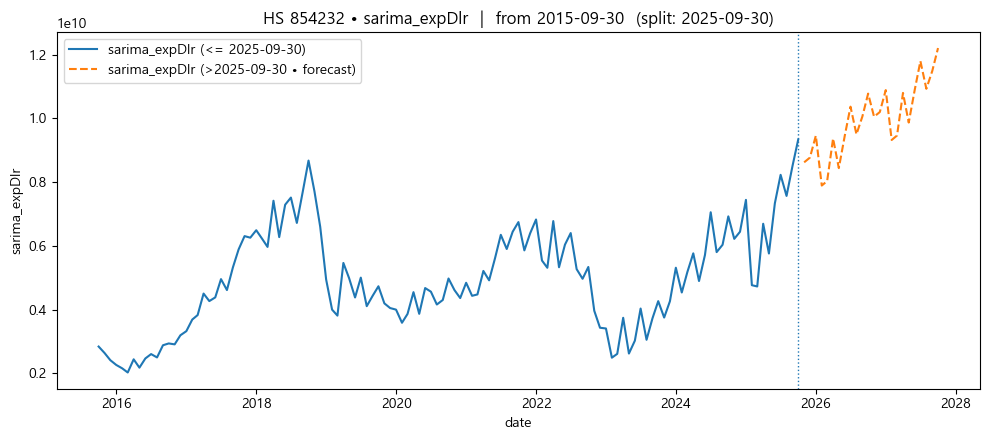

In [76]:
# 2) n개월 전부터 그려주고, 중심일 이후는 점선(예측)으로
plot_series_from_n_and_split(combined_df, hs_code="854232",
                             center_date="2025-09-30", n_months=120, col="sarima_expDlr",
                             save_path=None, show=True)

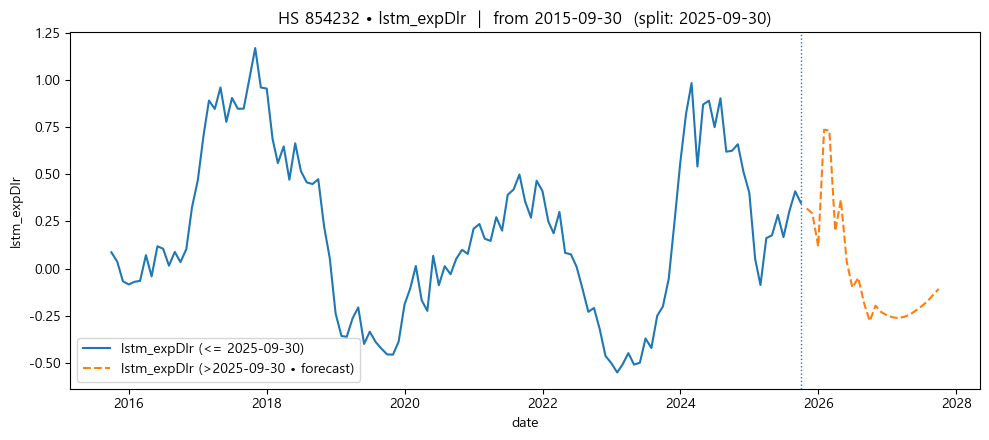

In [75]:
combined_df_diff = combined_df[['sarima_expDlr', 'lstm_expDlr']].pct_change(12).dropna(axis=0)
combined_df_diff['hs_code'] = "854232"
plot_series_from_n_and_split(combined_df_diff, hs_code="854232",
                             center_date="2025-09-30", n_months=120, col="lstm_expDlr",
                             save_path=None, show=True)

In [71]:
combined_df_diff.tail(24)

,sarima_expDlr,lstm_expDlr,hs_code
date,,,
2025-10-31,0.386198,0.318403,854232
2025-11-30,0.361169,0.292198,854232
2025-12-31,0.270843,0.117153,854232
2026-01-31,0.656268,0.735341,854232
2026-02-28,0.700045,0.731550,854232
2026-03-31,0.399941,0.199959,854232
2026-04-30,0.465115,0.363849,854232
2026-05-31,0.288895,0.037383,854232
2026-06-30,0.259991,-0.100571,854232
